In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import libpysal
from esda.moran import Moran_Local_BV, Moran_BV
from pyprojroot import here

In [26]:
# 1. Paths
ROOT        = here()
LSOA_PATH = ROOT/ "large" / "Lower_layer_Super_Output_Areas_December_2021_BGC.gpkg"
LSOA_MAPPING_PATH = ROOT / "data" / "LSOA_MSOA_LAD_Mapping.csv"
POPULATION_PATH = ROOT / "large" / "LSOA_population_by_singleyearofage_mid2024.csv"
IDACI_PATH = ROOT / "large" / "File_5_IoD2025_Scores_for_the_Indices_of_Deprivation.csv"
PARQUET_PATH = ROOT / "data" / "lsoa_travel_times.parquet"
INCOME_PATH = ROOT / "data"/ "income_datasetfinal.xlsx"
DLUA_PATH = ROOT / "data" / "DLUA_GLA.gpkg"
GLA_PATH = ROOT / "data" / "London_GLA_Boundary.shp"

LISA_CLUSTERS_OUTPUT_PATH = ROOT / "data" / "LISA_clusters.geojson"
LISA_BOUNDARIES_OUTPUT_PATH = ROOT / "data" / "LISA_clusters_outline.geojson"

OUTPUT_DIR  = ROOT / "outputs" / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Load LSOA shapefile 
gdf = gpd.read_file(LSOA_PATH)
print(f" LSOA_Dec_2021: {len(gdf):,} LSOAs | CRS: {gdf.crs}")

# Load LSOA mapping
mapping = pd.read_csv(LSOA_MAPPING_PATH, low_memory=False)
print(f" LSOA_Dec_2021: {len(mapping):,} LSOAs")

 LSOA_Dec_2021: 35,672 LSOAs | CRS: EPSG:27700
 LSOA_Dec_2021: 33,755 LSOAs


In [4]:
# 1. Load Population csv
pop = pd.read_csv(POPULATION_PATH, skiprows  = 3, low_memory=False)

# 2. Rename the LSOA column
pop = pop.rename(columns={'LSOA 2021 Code': 'LSOA21CD'})

# 3. Create 'Pop_11-16' by summing specific column ranges
cols_q_v = pop.iloc[:, 16:22]
cols_dd_di = pop.iloc[:, 107:113]
pop['Pop_11-16'] = cols_q_v.sum(axis=1) + cols_dd_di.sum(axis=1)

# 4. Retain only the required columns
pop = pop[['LSOA21CD', 'Pop_11-16', 'Total']]
print(f" Pop LSOAs: {len(pop):,} LSOAs")

 Pop LSOAs: 35,672 LSOAs


In [5]:
# 1. Load IoD2025 csv
idaci = pd.read_csv(IDACI_PATH, low_memory=False)

# 2. Rename the LSOA column
idaci = idaci.rename(columns={'LSOA code (2021)': 'LSOA21CD', 
                              'Index of Multiple Deprivation (IMD) Score': 'IMD_SCORE',
                              'Income Deprivation Affecting Children Index (IDACI) Score (rate)': 'IDACI_SCORE'})

#3. Retain only the required columns 
idaci = idaci[['LSOA21CD', 'IMD_SCORE', 'IDACI_SCORE']]
print(f" IDACI LSOAs: {len(idaci):,} LSOAs")

 IDACI LSOAs: 33,755 LSOAs


In [6]:
# Load travel time matrix
ttm = pd.read_parquet(PARQUET_PATH)
ttm = ttm.rename(columns={"lsoa_id": "LSOA21CD"})
print(f" TTM LSOAs: {len(ttm):,} LSOAs")

 TTM LSOAs: 4,994 LSOAs


In [7]:
# Load HH incomes after housing cost at MSOA-level 
income = pd.read_excel(INCOME_PATH,
                        sheet_name="Net income after housing costs",
                        header=3)

income = income[[
    "MSOA code",
    "MSOA name",
    "Region name",
    "Disposable (net) annual income after housing costs (£)"]].copy()

income = income.rename(columns={
    "MSOA code": "MSOA21CD",
    "MSOA name": "MSOA21NM",
    "Disposable (net) annual income after housing costs (£)": "income_ahc"})

print(f"\nIncome rows: {len(income):,}")


Income rows: 7,264


In [8]:
# Filter LSOAs within GLA Boundary
gla = gpd.read_file(GLA_PATH).to_crs("EPSG:27700")
gdf_london = gpd.clip(gdf, gla).copy()

print(f"London LSOA_Dec_2021: {len(gdf_london):,} LSOAs | CRS: {gdf_london.crs}")

London LSOA_Dec_2021: 5,128 LSOAs | CRS: EPSG:27700


In [9]:
# Merge data to LSOA level 
gdf_merged = (
    gdf_london
    .merge(mapping, on = "LSOA21CD", how = "left")
    .merge(pop, on="LSOA21CD", how="left")
    .merge(idaci, on="LSOA21CD", how="left")
    .merge(ttm, on="LSOA21CD", how="left")
    .merge(income, on = "MSOA21CD", how = "left")
)

# Filter via LAD24CD for Boroughs in London 
gdf_merged = gdf_merged[gdf_merged['LAD24CD'].str.startswith('E09', na=False)].copy()

print(f"Rows: {len(gdf_merged):,} | Columns: {gdf_merged.columns.tolist()}")
print(f"Nulls:\n{gdf_merged.isnull().sum()[gdf_merged.isnull().sum() > 0]}")

Rows: 4,994 | Columns: ['LSOA21CD', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'GlobalID', 'geometry', 'MSOA21CD', 'LAD24CD', 'LAD24NM', 'Pop_11-16', 'Total', 'IMD_SCORE', 'IDACI_SCORE', 'tt_transit_nearest_any', 'tt_transit_nearest_outstanding', 'tt_transit_nearest_top25_att8', 'tt_transit_nearest_top25_p8', 'tt_walk_nearest_any', 'tt_walk_nearest_outstanding', 'tt_walk_nearest_top25_att8', 'tt_walk_nearest_top25_p8', 'tt_cycle_nearest_any', 'tt_cycle_nearest_outstanding', 'tt_cycle_nearest_top25_att8', 'tt_cycle_nearest_top25_p8', 'tt_car_nearest_any', 'tt_car_nearest_outstanding', 'tt_car_nearest_top25_att8', 'tt_car_nearest_top25_p8', 'MSOA21NM', 'Region name', 'income_ahc']
Nulls:
tt_transit_nearest_any              1
tt_transit_nearest_outstanding      1
tt_transit_nearest_top25_att8       1
tt_transit_nearest_top25_p8         1
tt_walk_nearest_any                 1
tt_walk_nearest_outstanding       335
tt_walk_nearest_top25_att8        232
tt_walk_nearest_top25_p8

In [ ]:
P_CUTOFF     = 0.05
PENALTY_MINS = 120
QUADRANT_LABELS = {
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low",
}
COLOUR_MAP = {
    "High-High":       "#FF5F5F",   # Muted coral/red
    "Low-High":        "#E3A7A4",   # Light pink
    "High-Low":        "#5886C5",   # Light cornflower blue
    "Low-Low":         "#2D3D5E",   # Dark muted blue
    "Not Significant": "#979798",   # Dark slate
}
DRAW_ORDER = ["Not Significant", "High-Low", "Low-High", "Low-Low", "High-High"]

In [11]:
#Building KNN-8 spatial weights
w = libpysal.weights.KNN.from_dataframe(gdf_merged, k=8)
w.transform = "r"

In [12]:
# LISA helper
def run_lisa(gdf_in, w, x_col, p_cutoff=P_CUTOFF, penalty=PENALTY_MINS):
    gdf_out = gdf_in.copy().reset_index(drop=True)  # ensure clean 0-based index
    gdf_out[x_col] = gdf_out[x_col].fillna(penalty)

    x = gdf_out[x_col].values
    y = gdf_out["IDACI_SCORE"].values

    moran_local  = Moran_Local_BV(x, y, w, permutations=999, seed=42)
    moran_global = Moran_BV(x, y, w)

    gdf_out["lisa_cluster"] = "Not Significant"
    sig_mask = moran_local.p_sim < p_cutoff

    for pos_idx in np.where(sig_mask)[0]:  # positional indices
        gdf_out.at[pos_idx, "lisa_cluster"] = QUADRANT_LABELS[moran_local.q[pos_idx]]

    counts = gdf_out["lisa_cluster"].value_counts().to_dict()
    print(f"    Global I = {moran_global.I:.4f} | clusters: {counts}")

    return gdf_out, moran_global.I

In [13]:
gdf_result, global_I = run_lisa(
    gdf_merged,
    w,
    x_col="tt_transit_nearest_top25_p8"
)

    Global I = -0.1153 | clusters: {'Not Significant': 2546, 'Low-High': 711, 'Low-Low': 654, 'High-Low': 647, 'High-High': 436}


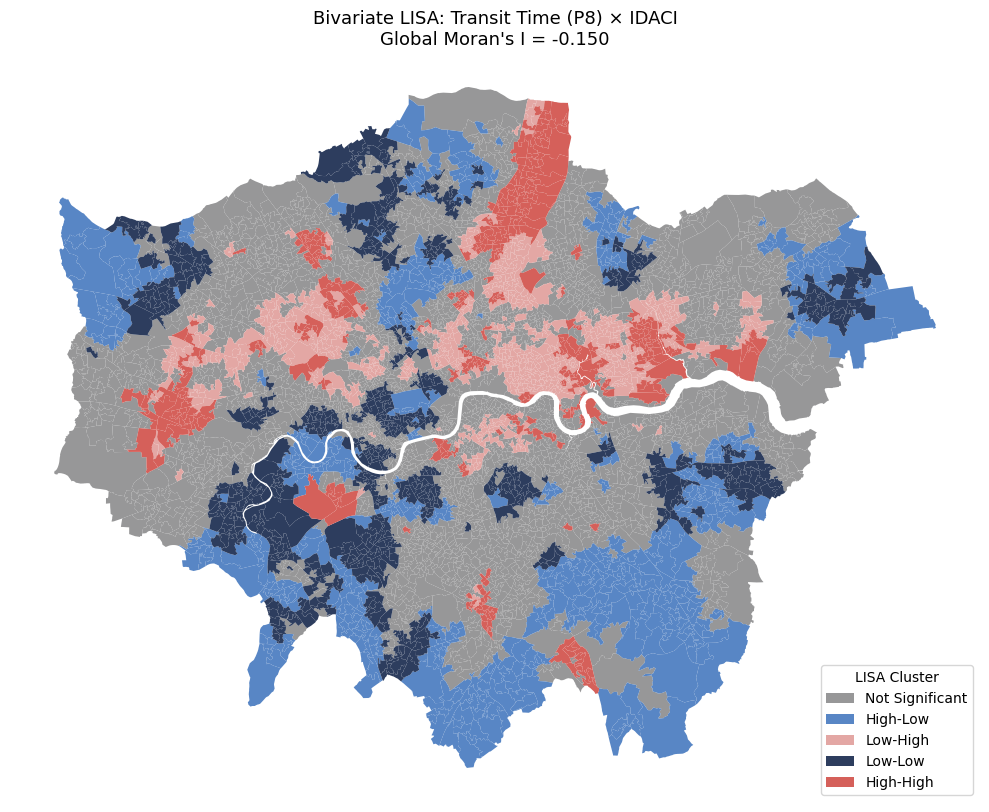

In [14]:
# Plot Figure for LSOA Clusters (All areas) 
fig, ax = plt.subplots(figsize=(10, 10))

for cluster in DRAW_ORDER:
    subset = gdf_result[gdf_result["lisa_cluster"] == cluster]
    subset.plot(
        ax=ax,
        color=COLOUR_MAP[cluster],
        edgecolor="none",
        linewidth=0
    )

# Legend (skip Not Significant or keep — your call)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOUR_MAP[k], label=k)
    for k in DRAW_ORDER 
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10, title="LISA Cluster")

ax.set_title(
    f"Bivariate LISA: Transit Time (P8) × IDACI\nGlobal Moran's I = -0.150",
    fontsize=13
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [28]:
DLUA = gpd.read_file(DLUA_PATH)
print(f"{len(DLUA):,} | CRS: {DLUA.crs}")

41 | CRS: EPSG:27700


In [29]:
gdf_result_clipped = gpd.clip(gdf_result,DLUA)

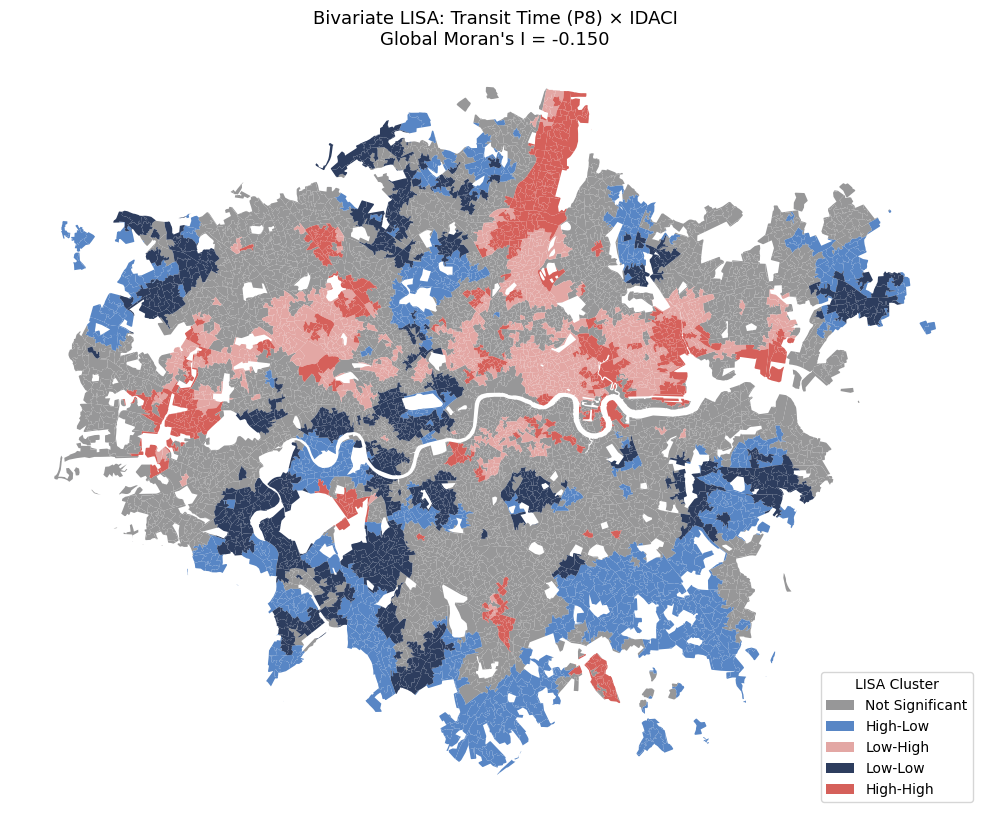

In [30]:
# Plot Figure for LSOA Clusters (Clipped to Urban Areas) 
fig, ax = plt.subplots(figsize=(10, 10))

for cluster in DRAW_ORDER:
    subset = gdf_result_clipped[gdf_result_clipped["lisa_cluster"] == cluster]
    subset.plot(
        ax=ax,
        color=COLOUR_MAP[cluster],
        edgecolor="none",
        linewidth=0
    )

# Legend (skip Not Significant or keep — your call)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOUR_MAP[k], label=k)
    for k in DRAW_ORDER 
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10, title="LISA Cluster")

ax.set_title(
    f"Bivariate LISA: Transit Time (P8) × IDACI\nGlobal Moran's I = -0.150",
    fontsize=13
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [47]:
summary = (
    gdf_result
    .groupby("lisa_cluster")
    .agg(
        pop_11_16_sum  = ("Pop_11-16",                    "sum"),
        idaci_median   = ("IDACI_SCORE",                  "median"),
        income_median   = ("income_ahc",                  "median"),
        tt_p8_median   = ("tt_transit_nearest_top25_p8",  "median"),
        car_p8_median   = ("tt_car_nearest_top25_p8",      "median"),
        walk_p8_median   = ("tt_walk_nearest_top25_p8",      "median")
    )
    .loc[DRAW_ORDER]
    .reset_index()
)

print(summary.to_string(index=False))

   lisa_cluster  pop_11_16_sum  idaci_median  income_median  tt_p8_median  car_p8_median  walk_p8_median
Not Significant         329184         0.423        39947.0          25.0            7.0            32.0
       High-Low          80081         0.155        48154.0          34.0            9.0            49.0
       Low-High          98655         0.614        33361.0          19.0            6.0            23.0
        Low-Low          76512         0.161        49289.0          20.0            5.0            23.0
      High-High          65002         0.619        32572.5          32.0            9.0            47.0


In [16]:
# 1. Pivot the data to get counts for each cluster type
summary = gdf_result.pivot_table(
    index='LAD24NM', 
    columns='lisa_cluster', 
    values='LSOA21CD', 
    aggfunc='nunique', 
    fill_value=0
)

# 2. Add a column for the total count of unique LSOAs per LAD
summary['Total_LSOAs'] = gdf_result.groupby('LAD24NM')['LSOA21CD'].nunique()

# 3. Clean up: reset index to make LAD24NM a column again
summary = summary.reset_index()

# 4. Calculate % High-High to 1 decimal place
summary['High-High_PERC'] = (summary['High-High'] / summary['Total_LSOAs'] * 100).round(1)

# Update reorder columns list to include the new percentage column
cols = [
    'LAD24NM', 'Total_LSOAs', 'High-High', 'High-High_PERC', 
    'Low-Low', 'High-Low', 'Low-High', 'Not Significant'
]
summary = summary[cols]

In [33]:
# Group by borough
borough_col = 'LSOA21NM'  # replace with your actual borough column e.g. LAD22NM

# Extract borough name from LSOA name if no direct borough column
gdf_result['borough'] = gdf_result['LSOA21NM'].str.extract(r'^(.+?)\s+\d+[A-Z]*$')

total = gdf_result.groupby('borough').agg(
    total_lsoas   = ('LSOA21CD', 'count'),
    total_pop     = ('Pop_11-16', 'sum')
).reset_index()

hh = gdf_result[gdf_result['lisa_cluster'] == 'High-High'].groupby('borough').agg(
    hh_lsoas = ('LSOA21CD', 'count'),
    hh_pop   = ('Pop_11-16', 'sum')
).reset_index()

borough_summary = total.merge(hh, on='borough', how='left').fillna(0)
borough_summary['pct_lsoas'] = (borough_summary['hh_lsoas'] / borough_summary['total_lsoas'] * 100).round(1)
borough_summary['pct_pop']   = (borough_summary['hh_pop']   / borough_summary['total_pop']   * 100).round(1)
borough_summary = borough_summary[borough_summary['hh_lsoas'] > 0].sort_values('pct_lsoas', ascending=False)

print(borough_summary[['borough','hh_lsoas','total_lsoas','pct_lsoas','hh_pop','total_pop','pct_pop']].to_string(index=False))

               borough  hh_lsoas  total_lsoas  pct_lsoas  hh_pop  total_pop  pct_pop
               Enfield      80.0          183       43.7 14998.0      28882     51.9
                Newham      66.0          185       35.7  9628.0      27295     35.3
         Tower Hamlets      37.0          169       21.9  4286.0      20558     20.8
              Haringey      30.0          147       20.4  3650.0      18319     19.9
             Islington      23.0          126       18.3  1998.0      11640     17.2
               Croydon      36.0          229       15.7  5232.0      31889     16.4
                Ealing      30.0          199       15.1  5310.0      28659     18.5
  Barking and Dagenham      16.0          115       13.9  3347.0      22357     15.0
                 Brent      21.0          181       11.6  3168.0      25267     12.5
                Barnet      24.0          220       10.9  3616.0      32970     11.0
            Hillingdon      13.0          170        7.6  2080.0 

In [31]:
lisa_clusters = gdf_result_clipped.to_crs("EPSG:4326")
lisa_clusters.to_file(LISA_CLUSTERS_OUTPUT_PATH, driver="GeoJSON")

In [32]:
lisa_boundaries = (
    gdf_result_clipped
    .to_crs("EPSG:4326")
    .dissolve(by="lisa_cluster")
    .reset_index()[["lisa_cluster", "geometry"]]
)
lisa_boundaries.to_file(LISA_BOUNDARIES_OUTPUT_PATH, driver="GeoJSON")

In [43]:
gdf_result['IDACI_SCORE'].median()

np.float64(0.408)

In [44]:
gdf_result['tt_transit_nearest_top25_p8'].median()

np.float64(25.0)

In [45]:
gdf_result['tt_walk_nearest_top25_p8'].median()

np.float64(32.0)

In [46]:
gdf_result['tt_car_nearest_top25_p8'].median()

np.float64(7.0)

lisa_cluster
High-High          80
Not Significant    64
High-Low           20
Low-High           10
Low-Low             9
Name: count, dtype: int64


c:\Users\benja\AppData\Local\Programs\Python\Python313\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


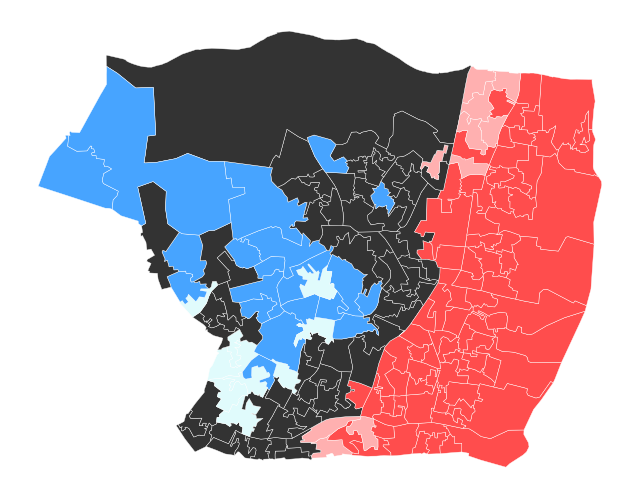

In [48]:
# Look at the specific area - Enfield
enfield = gdf_result[gdf_result['LSOA21NM'].str.startswith('Enfield')]
print(enfield['lisa_cluster'].value_counts())

# Visualise to confirm
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8,12))
colors = {
    'High-High': '#ff4d4d',
    'Low-High':  '#ffb0b0', 
    'High-Low':  '#47a4ff',
    'Low-Low':   '#e0fbfc',
    'Not Significant': '#333333'
}
enfield['color'] = enfield['lisa_cluster'].map(colors)
enfield.plot(ax=ax, color=enfield['color'], edgecolor='white', linewidth=0.3)
ax.set_axis_off()
plt.show()